In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score

In [11]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

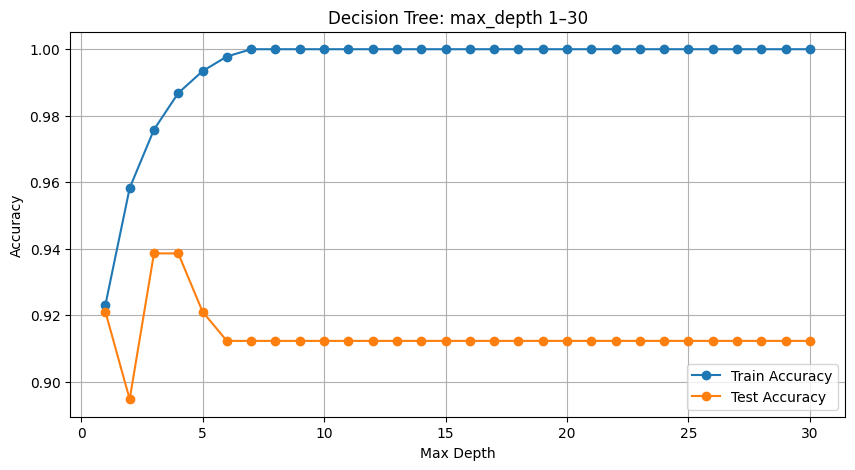

In [12]:
## Uji max_depth sampai 30
depths_30 = range(1, 31)

train_acc_30 = []
test_acc_30 = []

for d in depths_30:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc_30.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc_30.append(accuracy_score(y_test, model.predict(X_test)))

depth_results_30 = pd.DataFrame({
    "Depth": list(depths_30),
    "Train Accuracy": train_acc_30,
    "Test Accuracy": test_acc_30
})

depth_results_30

## Grafiknya:
plt.figure(figsize=(10, 5))
plt.plot(depths_30, train_acc_30, marker='o', label="Train Accuracy")
plt.plot(depths_30, test_acc_30, marker='o', label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: max_depth 1–30")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
## Tambahkan min_samples_split
split_values = [2, 5, 10, 20, 30]
split_results = []

for s in split_values:
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=s,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_acc_split = accuracy_score(y_train, model.predict(X_train))
    test_acc_split = accuracy_score(y_test, model.predict(X_test))
    
    split_results.append([s, train_acc_split, test_acc_split])
    print(f"min_samples_split={s} -> Train Acc={train_acc_split:.4f}, Test Acc={test_acc_split:.4f}")

split_df = pd.DataFrame(
    split_results,
    columns=["min_samples_split", "Train Accuracy", "Test Accuracy"]
)

split_df

min_samples_split=2 -> Train Acc=0.9934, Test Acc=0.9211
min_samples_split=5 -> Train Acc=0.9912, Test Acc=0.9211
min_samples_split=10 -> Train Acc=0.9868, Test Acc=0.9123
min_samples_split=20 -> Train Acc=0.9780, Test Acc=0.9386
min_samples_split=30 -> Train Acc=0.9758, Test Acc=0.9386


,min_samples_split,Train Accuracy,Test Accuracy
0,2,0.993407,0.921053
1,5,0.991209,0.921053
2,10,0.986813,0.912281
3,20,0.978022,0.938596
4,30,0.975824,0.938596


In [14]:
## Tambahkan min_samples_leaf
leaf_values = [1, 2, 5, 10, 20]
leaf_results = []

for l in leaf_values:
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=l,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_acc_leaf = accuracy_score(y_train, model.predict(X_train))
    test_acc_leaf = accuracy_score(y_test, model.predict(X_test))
    
    leaf_results.append([l, train_acc_leaf, test_acc_leaf])
    print(f"min_samples_leaf={l} -> Train Acc={train_acc_leaf:.4f}, Test Acc={test_acc_leaf:.4f}")

leaf_df = pd.DataFrame(
    leaf_results,
    columns=["min_samples_leaf", "Train Accuracy", "Test Accuracy"]
)

leaf_df

min_samples_leaf=1 -> Train Acc=0.9934, Test Acc=0.9211
min_samples_leaf=2 -> Train Acc=0.9912, Test Acc=0.9035
min_samples_leaf=5 -> Train Acc=0.9758, Test Acc=0.9211
min_samples_leaf=10 -> Train Acc=0.9626, Test Acc=0.9474
min_samples_leaf=20 -> Train Acc=0.9473, Test Acc=0.9035


,min_samples_leaf,Train Accuracy,Test Accuracy
0,1,0.993407,0.921053
1,2,0.991209,0.903509
2,5,0.975824,0.921053
3,10,0.962637,0.947368
4,20,0.947253,0.903509


In [15]:
## Bandingkan Decision Tree dengan Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

acc_logreg = accuracy_score(y_test, y_pred_logreg)

print("Logistic Regression Accuracy:", acc_logreg)

Logistic Regression Accuracy: 0.9824561403508771


In [16]:
## 5-Fold Cross Validation untuk Decision Tree
from sklearn.model_selection import cross_val_score

tree_cv = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_scores = cross_val_score(tree_cv, X, y, cv=5, scoring='accuracy')

print("Decision Tree CV Accuracy:", tree_scores)
print("Mean CV Accuracy:", tree_scores.mean())

Decision Tree CV Accuracy: [0.89473684 0.9122807  0.92982456 0.94736842 0.91150442]
Mean CV Accuracy: 0.91914299021891


In [17]:
## 5-Fold Cross Validation untuk Logistic Regression
logreg_cv_scores = cross_val_score(logreg_model, X, y, cv=5, scoring='accuracy')

print("Logistic Regression CV Accuracy:", logreg_cv_scores)
print("Mean CV Accuracy:", logreg_cv_scores.mean())

Logistic Regression CV Accuracy: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean CV Accuracy: 0.9806862288464524


In [ ]:
# Tabel Perbandingan Akhir
final_compare = pd.DataFrame({
    "Model": ["Decision Tree Default", "Decision Tree Gini", "Decision Tree Entropy", "Logistic Regression"],
    "Test Accuracy": [test_acc_default, acc_gini, acc_entropy, acc_logreg]
})

final_compare

NameError: name 'test_acc_default' is not defined

: 

In [ ]:
## CELL UNTUK MENENTUKAN DEPTH TERBAIK
best_idx = np.argmax(test_acc_30)
best_depth = list(depths_30)[best_idx]
best_test_acc = test_acc_30[best_idx]
best_train_acc = train_acc_30[best_idx]

print("Best Depth:", best_depth)
print("Best Train Accuracy:", best_train_acc)
print("Best Test Accuracy :", best_test_acc)